In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
df = pd.read_csv("/content/disney_plus_shows.csv")

print(df.head())
print(df.shape)
print(df.info())

     imdb_id                                       title  \
0  tt0147800                  10 Things I Hate About You   
1  tt7019028                        101 Dalmatian Street   
2  tt0115433                              101 Dalmatians   
3  tt0324941  101 Dalmatians 2: Patch's London Adventure   
4  tt0211181                              102 Dalmatians   

                                                plot    type  rated   year  \
0  A pretty, popular teenager can't go out on a d...   movie  PG-13   1999   
1  This series follows the lives of Delilah and D...  series    NaN  2018–   
2  An evil high-fashion designer plots to steal D...   movie      G   1996   
3  Being one of 101 takes its toll on Patch, who ...   movie      G   2002   
4  Cruella DeVil gets out of prison and goes afte...   movie      G   2000   

   released_at           added_at  runtime  \
0  31 Mar 1999  November 12, 2019   97 min   
1  25 Mar 2019  February 28, 2020      NaN   
2  27 Nov 1996  November 12, 201

In [13]:
data = df[['year', 'runtime', 'imdb_rating', 'metascore', 'type']]

In [16]:
encoder = LabelEncoder()

data['type'] = encoder.fit_transform(data['type'])

print(data.head())

   year  runtime  imdb_rating  metascore  type
0  1999       97          7.3       70.0     0
2  1996      103          5.7       49.0     0
4  2000      100          4.9       35.0     0
6  1954      127          7.2       83.0     0
7  1998       95          7.2       77.0     0


In [17]:
X = data[['year', 'runtime', 'imdb_rating', 'metascore']]
y = data['type']

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
y_pred = knn.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


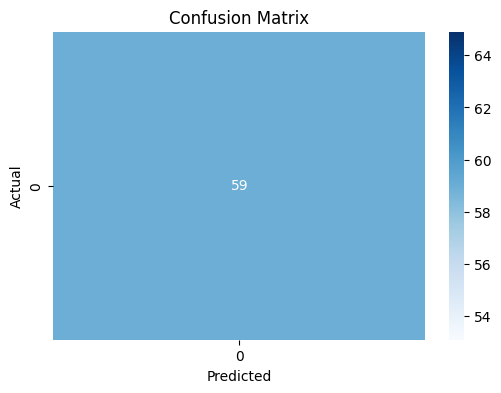

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59



In [25]:
accuracy_scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test, pred)

    accuracy_scores.append(score)

print(accuracy_scores)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


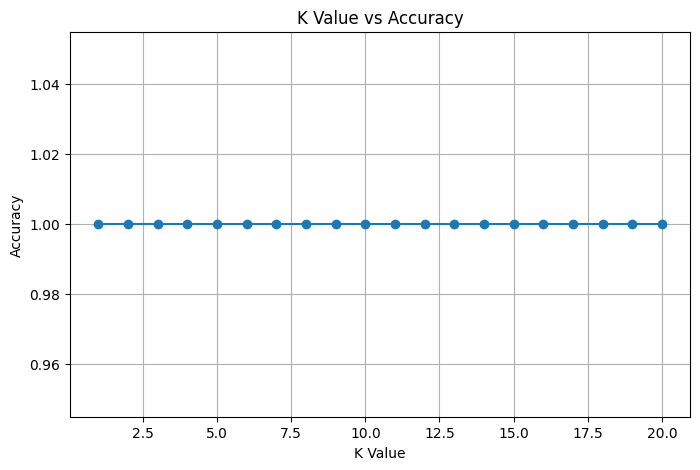

Best K: 1
Best Accuracy: 1.0


In [29]:
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, pred)
    )

plt.figure(figsize=(8,5))
plt.plot(range(1,21), accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.grid(True)
plt.show()

best_k = np.argmax(accuracies) + 1
print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

In [26]:
best_k = accuracy_scores.index(max(accuracy_scores)) + 1

print("Best K Value:", best_k)
print("Best Accuracy:", max(accuracy_scores))

Best K Value: 1
Best Accuracy: 1.0
